In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('/content/Telco-Customer-Churn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.shape

(7043, 21)

**Data Cleaning**

Drop non-informative column (customerID)

In [ ]:
df.drop('customerID', axis=1, inplace=True)

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Fix TotalCharges data type issue

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

Check missing values:

In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


Handle missing values in TotalCharges

In [ ]:
df['TotalCharges'].head()

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65


Missing values in the TotalCharges attribute were handled using median imputation to preserve dataset size and reduce the influence of extreme values. This approach ensures robustness while maintaining data integrity for predictive modeling.

In [ ]:
median_total_charges = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_total_charges, inplace=True)

/tmp/ipython-input-4130185627.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(median_total_charges, inplace=True)


In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


Check number of duplicate rows

In [ ]:
df.duplicated().sum()

np.int64(22)

Remove duplicates

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

Outlier Detection (Numerical Features Only)

In [ ]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [ ]:
outlier_summary = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = outliers.shape[0]

In [ ]:
outlier_summary

{'tenure': 0, 'MonthlyCharges': 0, 'TotalCharges': 0}

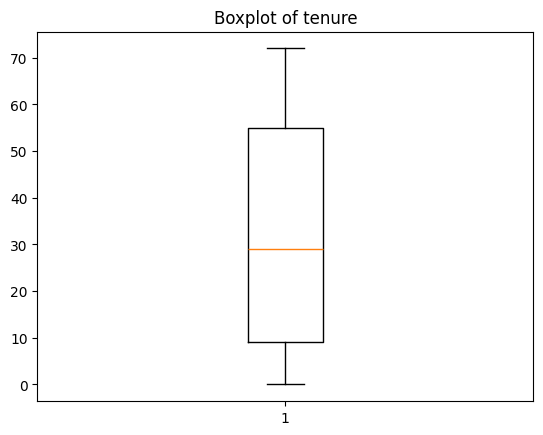

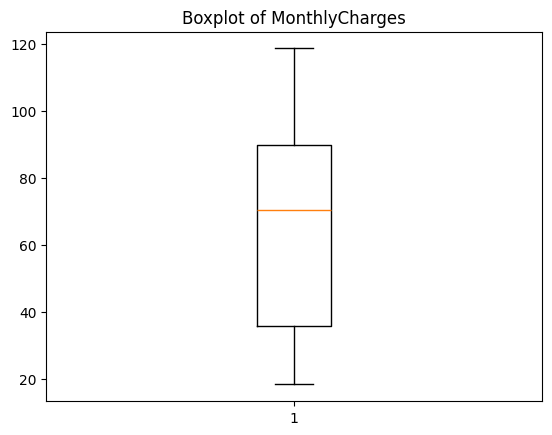

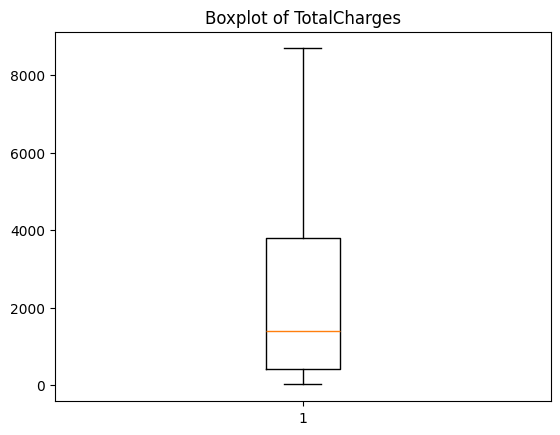

In [ ]:
import matplotlib.pyplot as plt

for col in numerical_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Outlier detection was performed on numerical attributes using the interquartile range (IQR) method. Although the presence of extreme values was observed, these data points were not removed, as they represent genuine customer behavior such as long-term subscriptions and higher billing amounts. Retaining these values ensures that the models learn from realistic business scenarios.

**Exploratory Data Analysis (EDA)**

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5164
Yes,1857


In [ ]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2210,1643
One year,1307,166
Two year,1647,48


In [ ]:
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5164.0,37.640782,24.083296,0.0,15.0,38.0,61.0,72.0
Yes,1857.0,18.088853,19.546231,1.0,2.0,10.0,29.0,72.0


In [ ]:
df.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5164.0,61.344878,31.069815,18.25,25.1,64.5,88.4625,118.75
Yes,1857.0,74.604308,24.597504,18.85,56.5,79.7,94.2500,118.35


In [ ]:
pd.crosstab(df['InternetService'], df['Churn'])

Churn,No,Yes
InternetService,,
DSL,1962,457
Fiber optic,1799,1291
No,1403,109


In [ ]:
pd.crosstab(df['PaymentMethod'], df['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1065
Mailed check,1294,302


In [ ]:
pd.crosstab(df['SeniorCitizen'], df['Churn'])

Churn,No,Yes
SeniorCitizen,,
0,4498,1382
1,666,475


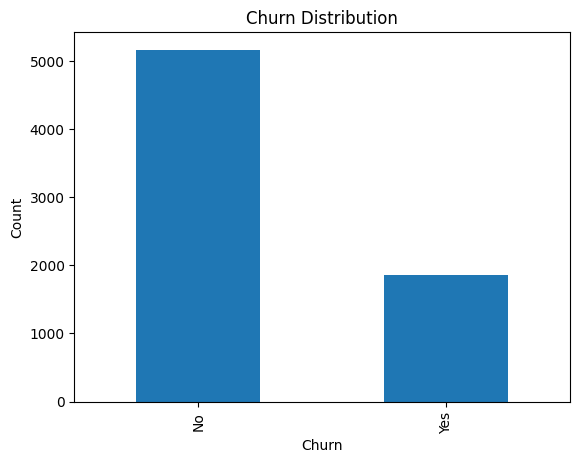

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
df['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

<Figure size 640x480 with 0 Axes>

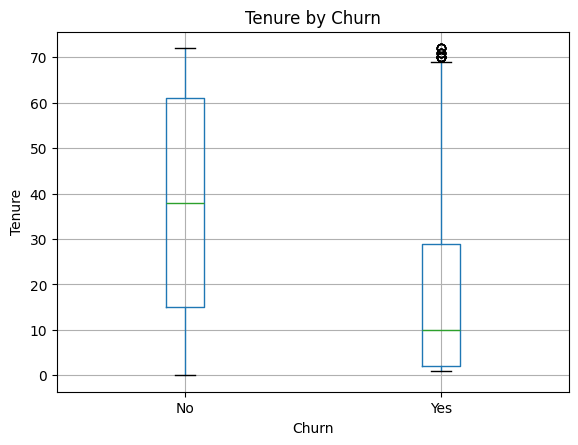

In [ ]:
plt.figure()
df.boxplot(column='tenure', by='Churn')
plt.title('Tenure by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()

<Figure size 640x480 with 0 Axes>

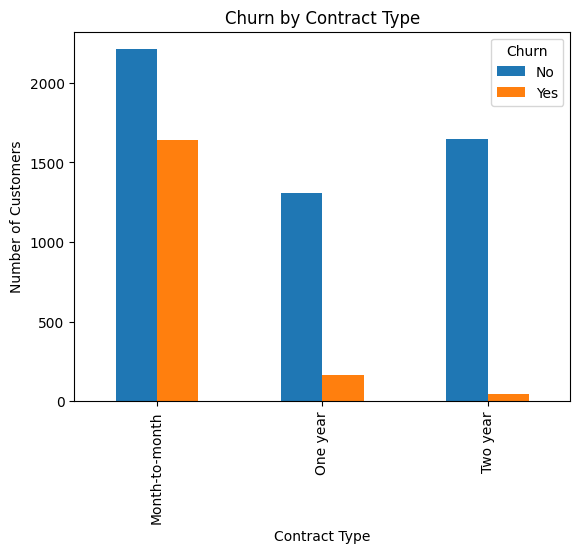

In [ ]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'])

plt.figure()
contract_churn.plot(kind='bar')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.title('Churn by Contract Type')
plt.show()

<Figure size 640x480 with 0 Axes>

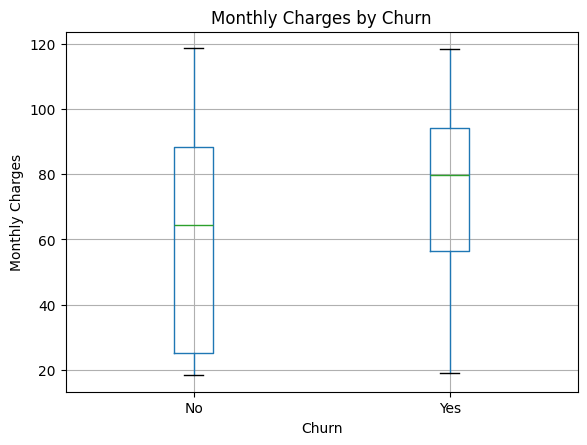

In [ ]:
plt.figure()
df.boxplot(column='MonthlyCharges', by='Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.title('Monthly Charges by Churn')
plt.suptitle('')
plt.show()

<Figure size 640x480 with 0 Axes>

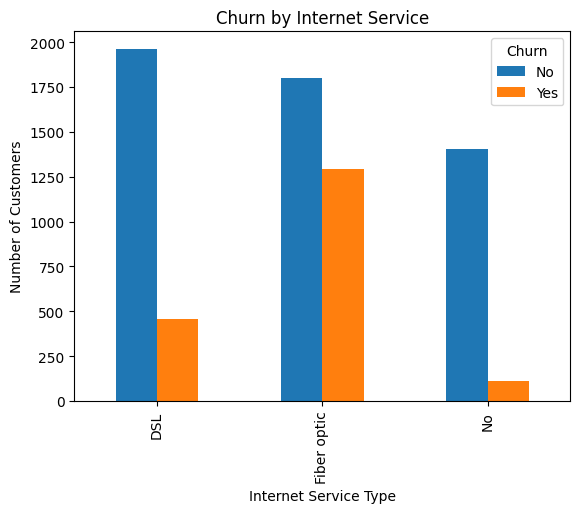

In [ ]:
internet_churn = pd.crosstab(df['InternetService'], df['Churn'])

plt.figure()
internet_churn.plot(kind='bar')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')
plt.title('Churn by Internet Service')
plt.show()

<Figure size 640x480 with 0 Axes>

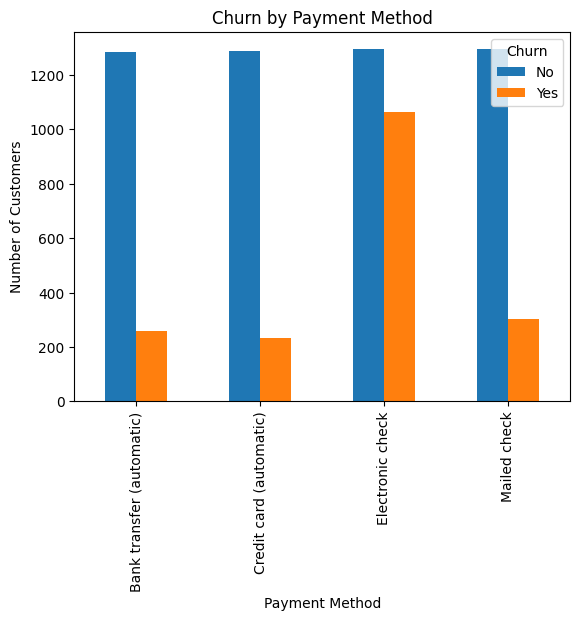

In [ ]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'])

plt.figure()
payment_churn.plot(kind='bar')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.title('Churn by Payment Method')
plt.show()

<Figure size 640x480 with 0 Axes>

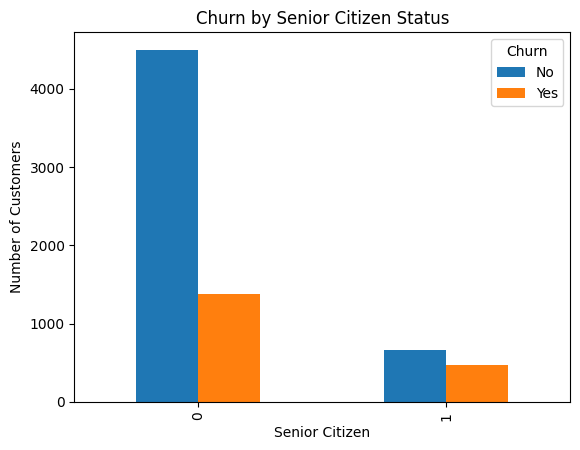

In [ ]:
senior_churn = pd.crosstab(df['SeniorCitizen'], df['Churn'])

plt.figure()
senior_churn.plot(kind='bar')
plt.xlabel('Senior Citizen')
plt.ylabel('Number of Customers')
plt.title('Churn by Senior Citizen Status')
plt.show()

<Figure size 640x480 with 0 Axes>

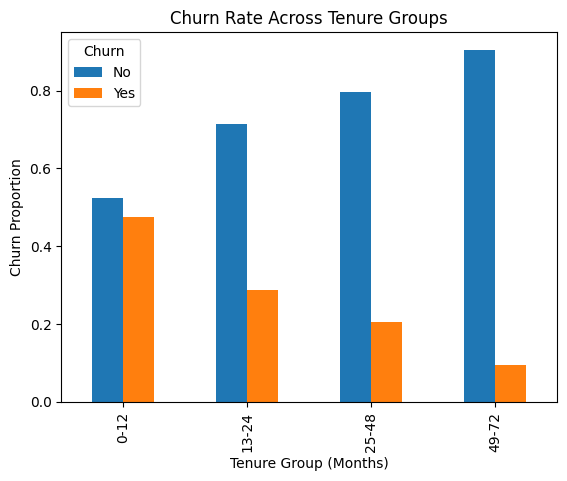

In [ ]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12', '13-24', '25-48', '49-72']
)

tenure_churn = pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index')

plt.figure()
tenure_churn.plot(kind='bar')
plt.xlabel('Tenure Group (Months)')
plt.ylabel('Churn Proportion')
plt.title('Churn Rate Across Tenure Groups')
plt.show()

<Figure size 640x480 with 0 Axes>

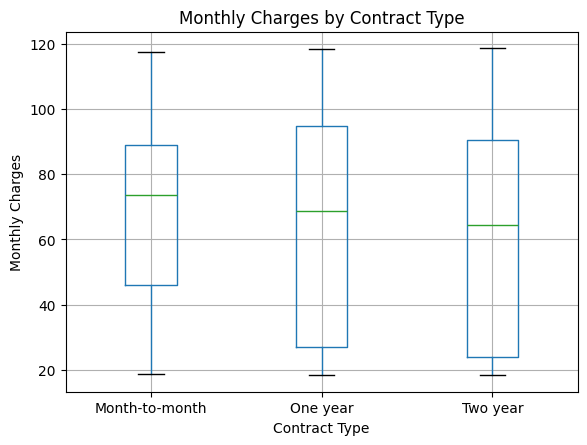

In [ ]:
plt.figure()
df.boxplot(column='MonthlyCharges', by='Contract')
plt.xlabel('Contract Type')
plt.ylabel('Monthly Charges')
plt.title('Monthly Charges by Contract Type')
plt.suptitle('')
plt.show()

<Figure size 640x480 with 0 Axes>

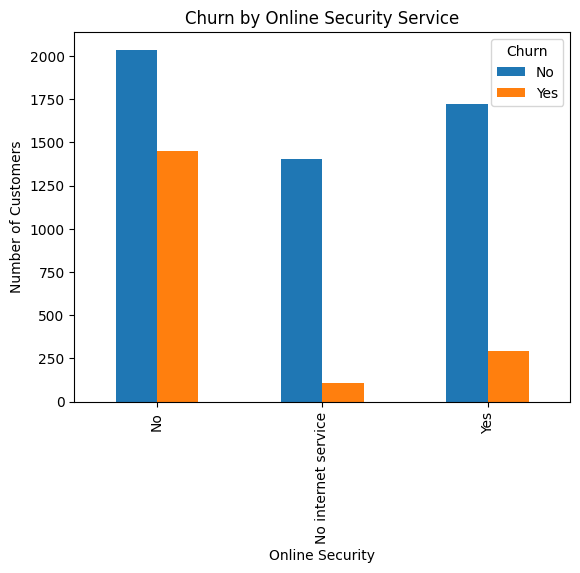

In [ ]:
security_churn = pd.crosstab(df['OnlineSecurity'], df['Churn'])

plt.figure()
security_churn.plot(kind='bar')
plt.xlabel('Online Security')
plt.ylabel('Number of Customers')
plt.title('Churn by Online Security Service')
plt.show()

<Figure size 640x480 with 0 Axes>

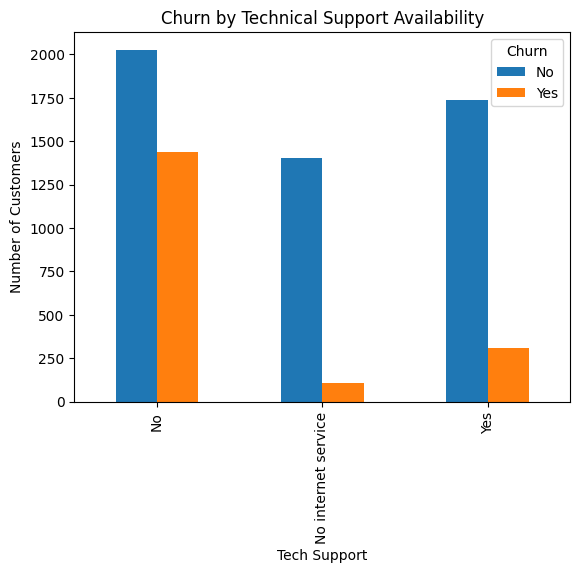

In [ ]:
tech_churn = pd.crosstab(df['TechSupport'], df['Churn'])

plt.figure()
tech_churn.plot(kind='bar')
plt.xlabel('Tech Support')
plt.ylabel('Number of Customers')
plt.title('Churn by Technical Support Availability')
plt.show()

<Figure size 640x480 with 0 Axes>

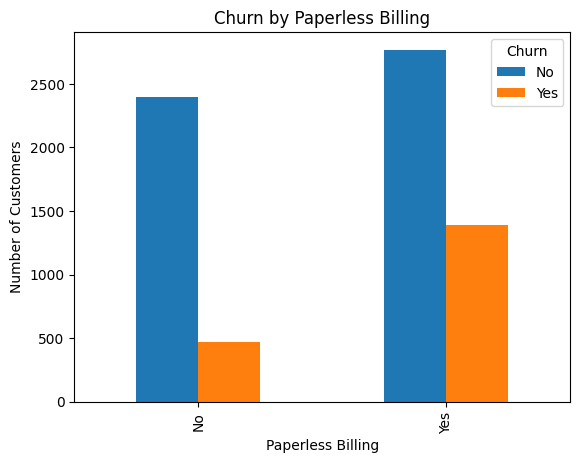

In [ ]:
paperless_churn = pd.crosstab(df['PaperlessBilling'], df['Churn'])

plt.figure()
paperless_churn.plot(kind='bar')
plt.xlabel('Paperless Billing')
plt.ylabel('Number of Customers')
plt.title('Churn by Paperless Billing')
plt.show()

<Figure size 640x480 with 0 Axes>

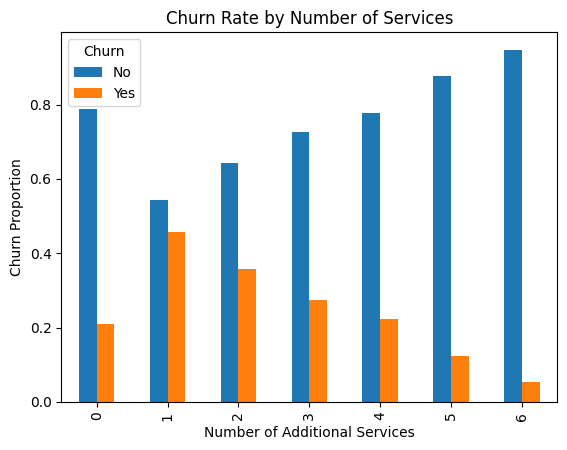

In [ ]:
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df['ServiceCount'] = df[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)

service_churn = pd.crosstab(df['ServiceCount'], df['Churn'], normalize='index')

plt.figure()
service_churn.plot(kind='bar')
plt.xlabel('Number of Additional Services')
plt.ylabel('Churn Proportion')
plt.title('Churn Rate by Number of Services')
plt.show()

<Figure size 640x480 with 0 Axes>

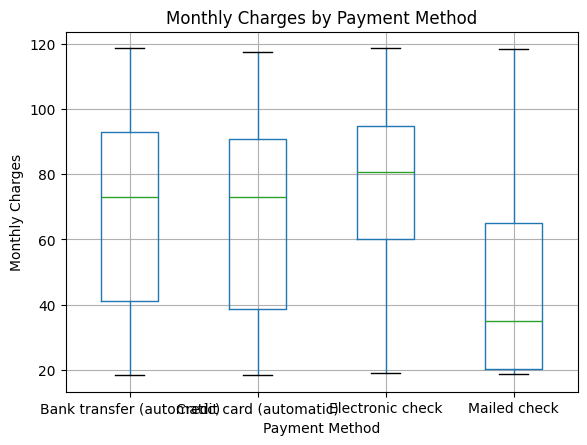

In [ ]:
plt.figure()
df.boxplot(column='MonthlyCharges', by='PaymentMethod')
plt.xlabel('Payment Method')
plt.ylabel('Monthly Charges')
plt.title('Monthly Charges by Payment Method')
plt.suptitle('')
plt.show()

<Figure size 640x480 with 0 Axes>

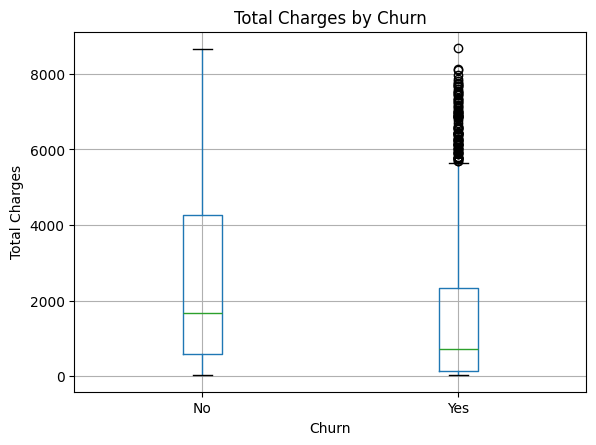

In [ ]:
plt.figure()
df.boxplot(column='TotalCharges', by='Churn')
plt.xlabel('Churn')
plt.ylabel('Total Charges')
plt.title('Total Charges by Churn')
plt.suptitle('')
plt.show()

<Figure size 640x480 with 0 Axes>

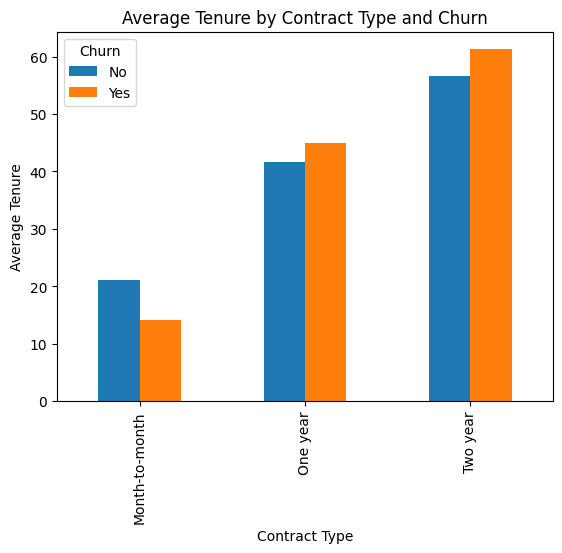

In [ ]:
contract_tenure = df.groupby(['Contract', 'Churn'])['tenure'].mean().unstack()

plt.figure()
contract_tenure.plot(kind='bar')
plt.xlabel('Contract Type')
plt.ylabel('Average Tenure')
plt.title('Average Tenure by Contract Type and Churn')
plt.show()

<Figure size 640x480 with 0 Axes>

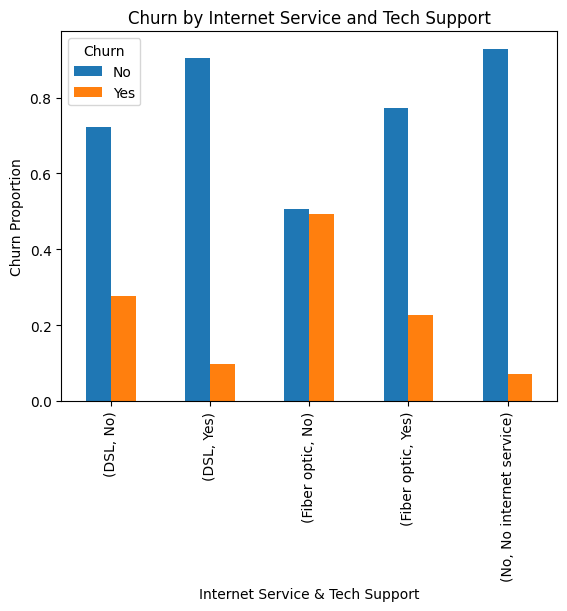

In [ ]:
service_support = pd.crosstab(
    [df['InternetService'], df['TechSupport']],
    df['Churn'],
    normalize='index'
)

plt.figure()
service_support.plot(kind='bar')
plt.xlabel('Internet Service & Tech Support')
plt.ylabel('Churn Proportion')
plt.title('Churn by Internet Service and Tech Support')
plt.show()

<Figure size 640x480 with 0 Axes>

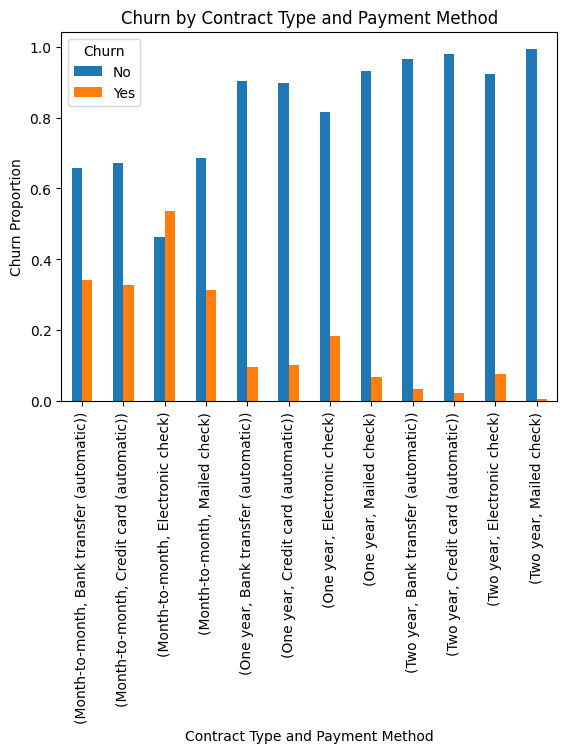

In [ ]:
contract_payment = pd.crosstab(
    [df['Contract'], df['PaymentMethod']],
    df['Churn'],
    normalize='index'
)

plt.figure()
contract_payment.plot(kind='bar')
plt.xlabel('Contract Type and Payment Method')
plt.ylabel('Churn Proportion')
plt.title('Churn by Contract Type and Payment Method')
plt.show()

/tmp/ipython-input-1027803574.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_charge = df.groupby('TenureGroup')['MonthlyCharges'].mean()


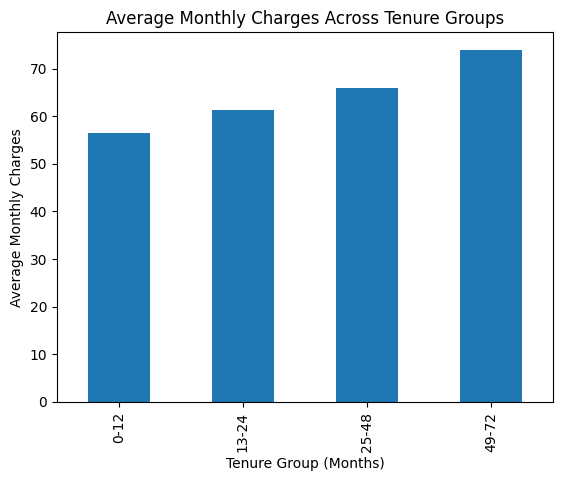

In [ ]:
tenure_charge = df.groupby('TenureGroup')['MonthlyCharges'].mean()

plt.figure()
tenure_charge.plot(kind='bar')
plt.xlabel('Tenure Group (Months)')
plt.ylabel('Average Monthly Charges')
plt.title('Average Monthly Charges Across Tenure Groups')
plt.show()

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

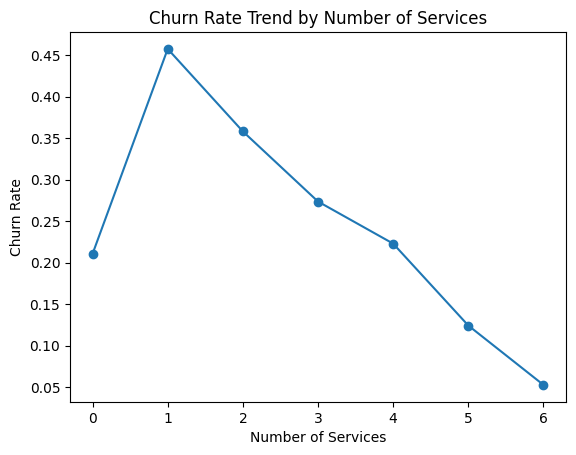

In [ ]:
service_churn_rate = (
    df.groupby('ServiceCount')['Churn'].mean()
)

plt.figure()
plt.plot(service_churn_rate.index, service_churn_rate.values, marker='o')
plt.xlabel('Number of Services')
plt.ylabel('Churn Rate')
plt.title('Churn Rate Trend by Number of Services')
plt.show()

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ServiceCount
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,25-48,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12,2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,25-48,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12,0


**Feature Engineering**

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ServiceCount
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,25-48,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12,2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,25-48,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12,0


created TenureGroup and ServiceCount only for EDA

For now, we remove them to avoid data leakage and keep models clean.

In [ ]:
df.drop(columns=['TenureGroup', 'ServiceCount'], inplace=True, errors='ignore')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

Identify Numerical and Categorical Features

In [ ]:
numerical_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = df.select_dtypes(include='object').columns.tolist()

In [ ]:
numerical_features

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [ ]:
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

Lable Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


Train–Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Feature Scaling (ONLY for Logistic Regression)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)
X_test_scaled[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

In [ ]:
X_train_scaled

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2629,1,0.0,0,0,0.027778,1,0,1,0,0,0,0,0,0,0,0,1,0.521891,0.014061
2650,0,0.0,0,0,0.208333,1,2,1,2,0,2,0,0,0,0,1,1,0.657711,0.148143
1418,1,0.0,1,1,0.930556,1,2,1,0,2,0,0,0,2,0,1,0,0.709453,0.733243
5774,1,0.0,0,0,0.069444,1,0,0,0,2,0,2,0,2,0,1,0,0.471144,0.037047
2425,1,0.0,0,0,0.361111,1,0,2,1,1,1,1,1,1,0,1,2,0.020398,0.056820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6696,1,0.0,0,0,0.069444,1,2,1,0,2,2,0,0,2,0,0,2,0.779104,0.055533
2094,0,0.0,0,0,0.250000,1,0,2,1,1,1,1,1,1,0,0,3,0.013930,0.043025
4991,0,0.0,0,0,0.805556,1,0,1,2,2,2,0,2,2,1,1,2,0.877612,0.707020
6882,0,1.0,0,0,0.986111,1,2,1,2,2,0,2,2,0,1,1,1,0.809950,0.826499


In [ ]:
X_test_scaled

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
5627,1,1.0,1,0,0.097222,1,2,1,0,0,0,0,0,0,0,1,2,0.563184,0.053820
6126,1,1.0,0,0,0.263889,1,0,1,0,0,2,0,2,2,0,1,1,0.772637,0.202984
2361,0,0.0,0,1,0.013889,1,0,0,0,0,0,0,0,0,0,0,3,0.275622,0.003127
2201,0,0.0,0,0,0.500000,1,0,0,2,2,2,2,2,2,1,0,0,0.672637,0.344417
832,0,0.0,1,1,0.972222,1,0,0,2,2,2,2,0,2,1,0,1,0.555721,0.600448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2310,1,0.0,0,0,1.000000,0,1,0,2,2,2,2,2,2,2,1,0,0.452239,0.513037
2685,0,0.0,1,0,1.000000,1,2,1,2,2,2,0,2,0,2,0,0,0.819900,0.844131
1104,1,0.0,0,0,0.583333,1,0,2,1,1,1,1,1,1,1,1,3,0.012935,0.094687
5704,0,0.0,1,0,0.263889,1,2,1,0,0,0,0,2,0,0,1,2,0.682587,0.178347


Categorical variables were transformed using label encoding to convert qualitative attributes into numerical form. This approach was selected to maintain computational simplicity and compatibility with tree-based algorithms such as Random Forest and XGBoost. Feature scaling was applied only for Logistic Regression to meet algorithmic assumptions, while tree-based models were trained on unscaled features.

**Data Modelling**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

Logistic Regression (Baseline Model)

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}

lr_grid = GridSearchCV(
    lr,
    lr_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear']},
             scoring='f1')

In [ ]:
best_lr = lr_grid.best_estimator_
best_lr

LogisticRegression(C=10, max_iter=1000, solver='liblinear')

In [ ]:
lr_preds = best_lr.predict(X_test_scaled)

print("Logistic Regression Classification Report:\n")
print(classification_report(y_test, lr_preds))

Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.53      0.58       372

    accuracy                           0.80      1405
   macro avg       0.74      0.71      0.72      1405
weighted avg       0.79      0.80      0.79      1405



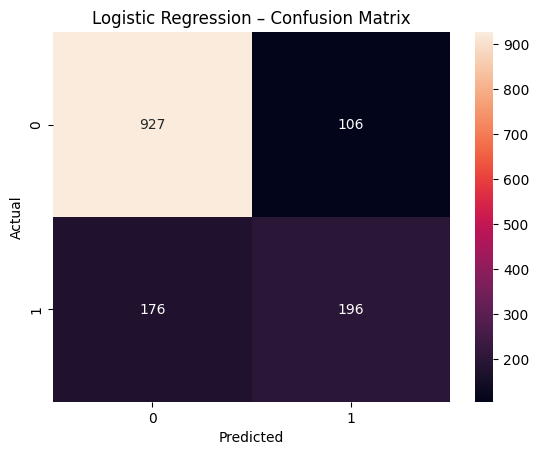

In [ ]:
cm_lr = confusion_matrix(y_test, lr_preds)

sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Logistic Regression – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest Classifier

In [ ]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [ ]:
best_rf = rf_grid.best_estimator_
best_rf

RandomForestClassifier(max_depth=10, min_samples_split=5, random_state=42)

In [ ]:
rf_preds = best_rf.predict(X_test)

print("Random Forest Classification Report:\n")
print(classification_report(y_test, rf_preds))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.64      0.50      0.56       372

    accuracy                           0.79      1405
   macro avg       0.74      0.70      0.71      1405
weighted avg       0.78      0.79      0.79      1405



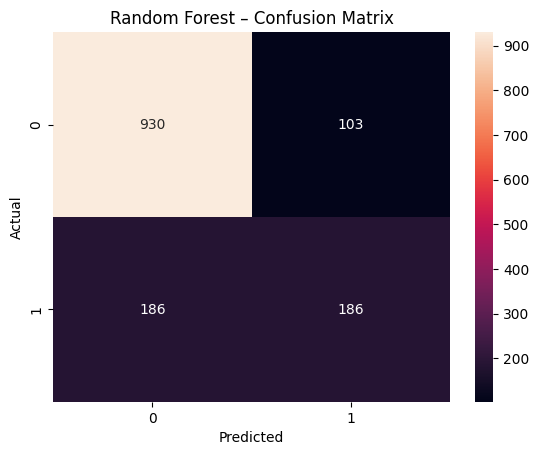

In [ ]:
cm_rf = confusion_matrix(y_test, rf_preds)

sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

XGBoost Classifier

In [ ]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:20:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='f1')

In [ ]:
best_xgb = xgb_grid.best_estimator_
best_xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_preds = best_xgb.predict(X_test)

print("XGBoost Classification Report:\n")
print(classification_report(y_test, xgb_preds))

XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.51      0.57       372

    accuracy                           0.79      1405
   macro avg       0.74      0.70      0.72      1405
weighted avg       0.78      0.79      0.79      1405



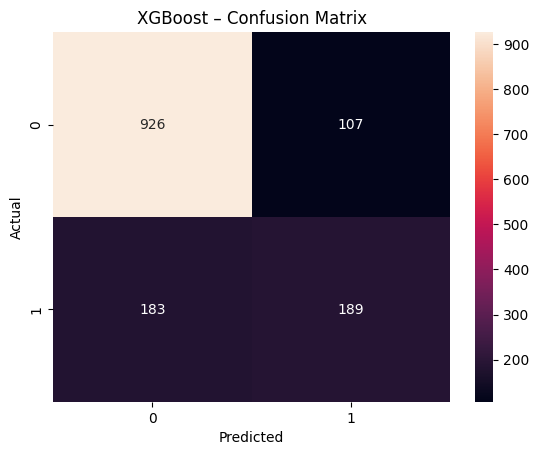

In [ ]:
cm_xgb = confusion_matrix(y_test, xgb_preds)

sns.heatmap(cm_xgb, annot=True, fmt='d')
plt.title("XGBoost – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model Comparison

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Best Parameters': [
        lr_grid.best_params_,
        rf_grid.best_params_,
        xgb_grid.best_params_
    ]
})

comparison

,Model,Best Parameters
0,Logistic Regression,"{'C': 10, 'solver': 'liblinear'}"
1,Random Forest,"{'max_depth': 10, 'min_samples_split': 5, 'n_e..."
2,XGBoost,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."


In [ ]:
lr_accuracy = accuracy_score(y_test, lr_preds)
rf_accuracy = accuracy_score(y_test, rf_preds)
xgb_accuracy = accuracy_score(y_test, xgb_preds)

In [ ]:
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

Logistic Regression Accuracy: 0.7993
Random Forest Accuracy: 0.7943
XGBoost Accuracy: 0.7936


In [ ]:
accuracy_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_accuracy, rf_accuracy, xgb_accuracy]
})

accuracy_comparison

,Model,Accuracy
0,Logistic Regression,0.799288
1,Random Forest,0.794306
2,XGBoost,0.793594


In [ ]:
import joblib

joblib.dump(best_lr, "logistic_regression_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

**XAI – Logistic Regression (Global Interpretability)**

In [ ]:
lr_coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

lr_coefficients

,Feature,Coefficient
17,MonthlyCharges,2.512758
18,TotalCharges,2.331792
15,PaperlessBilling,0.363591
1,SeniorCitizen,0.270735
7,InternetService,0.250094
6,MultipleLines,0.088993
16,PaymentMethod,0.055586
2,Partner,0.028103
0,gender,0.014786
13,StreamingMovies,-0.007704


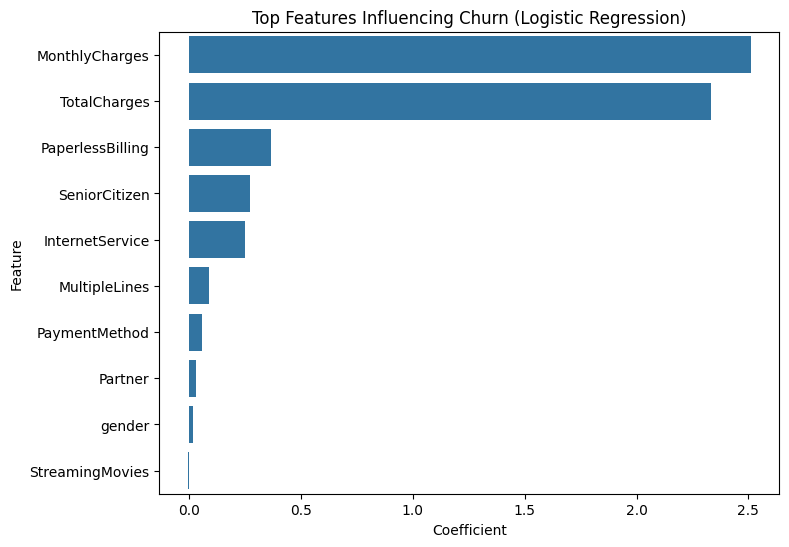

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=lr_coefficients.head(10),
    x='Coefficient',
    y='Feature'
)
plt.title("Top Features Influencing Churn (Logistic Regression)")
plt.show()

XAI – Random Forest (Feature Importance)

In [ ]:
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)


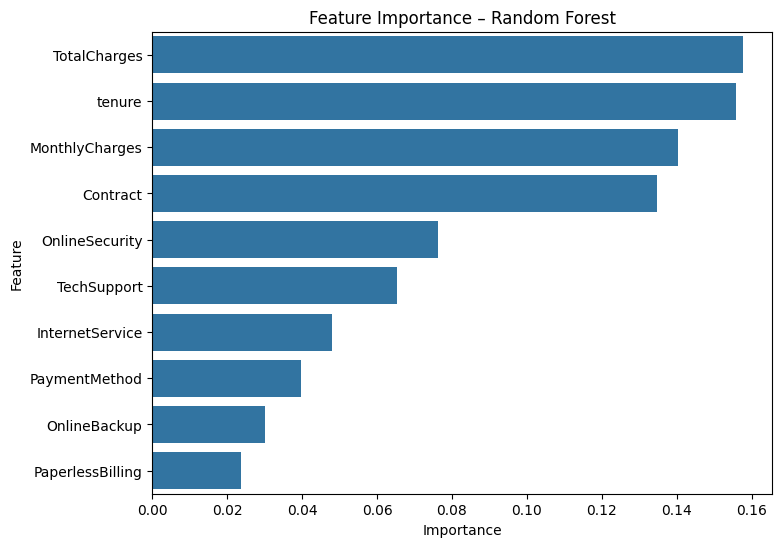

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=rf_importance.head(10),
    x='Importance',
    y='Feature'
)
plt.title("Feature Importance – Random Forest")
plt.show()

XAI – XGBoost with SHAP (Advanced Explainability)

In [ ]:
!pip install shap

 95%|=================== | 1338/1405 [00:18<00:00]       

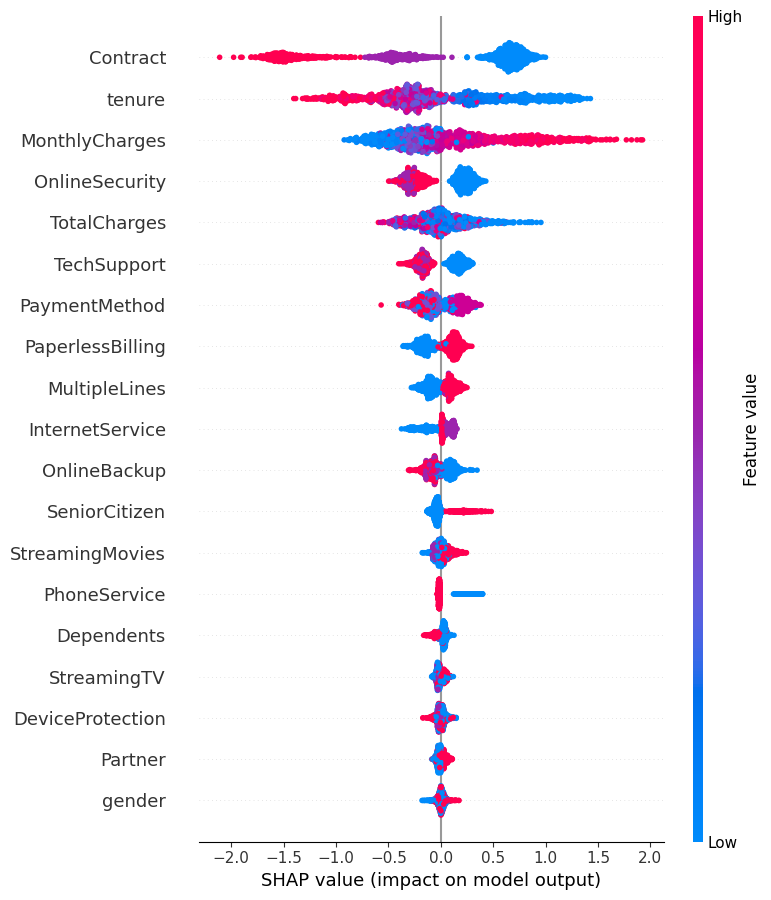

In [ ]:
import shap
explainer = shap.Explainer(best_xgb, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

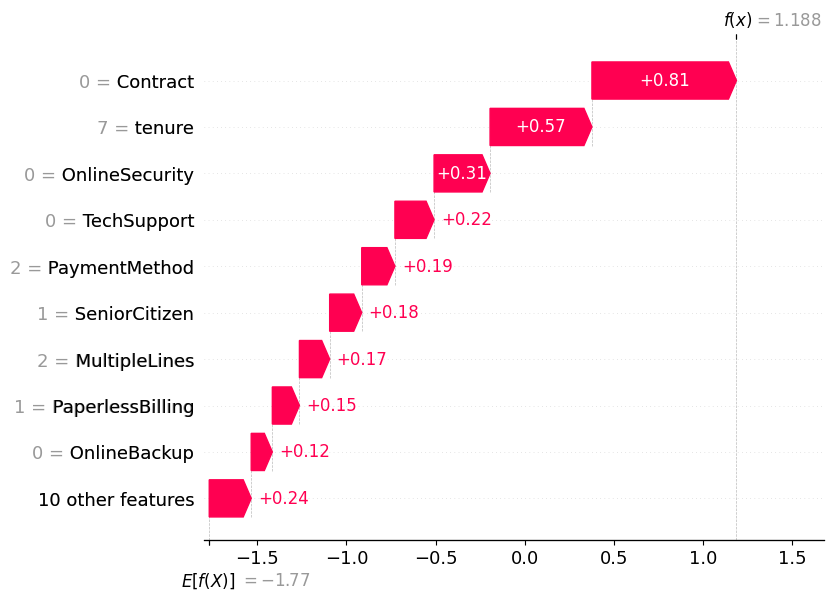

In [ ]:
shap.plots.waterfall(shap_values[0])

Explainable AI techniques were applied to interpret churn predictions generated by machine learning models. Logistic Regression coefficients provided direct insight into the direction and magnitude of feature influence. Random Forest feature importance highlighted key variables contributing to model decisions. Additionally, SHAP values were employed for XGBoost to offer both global and local explanations, enabling transparent understanding of individual churn predictions. These interpretability methods support business trust and actionable decision-making.

**Business Impact of AI-Based Churn Prediction**

Churn Risk Segmentation

Instead of only predicting Yes / No, businesses need risk levels.

In [ ]:
churn_probabilities = best_xgb.predict_proba(X_test)[:, 1]

risk_df = X_test.copy()
risk_df['Churn_Probability'] = churn_probabilities
risk_df['Actual_Churn'] = y_test.values

In [ ]:
def risk_segment(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

risk_df['Risk_Segment'] = risk_df['Churn_Probability'].apply(risk_segment)

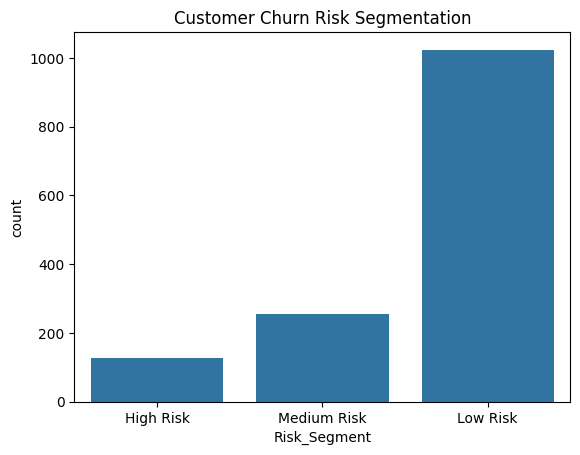

In [ ]:
sns.countplot(data=risk_df, x='Risk_Segment')
plt.title("Customer Churn Risk Segmentation")
plt.show()

Priority Customer Identification

Businesses must prioritize high-value customers.

In [ ]:
priority_customers = risk_df[
    (risk_df['Risk_Segment'] == 'High Risk') &
    (risk_df['MonthlyCharges'] > risk_df['MonthlyCharges'].median())
]

priority_customers.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Probability,Actual_Churn,Risk_Segment
5627,1,1,1,0,7,1,2,1,0,0,...,0,0,0,1,2,74.85,485.25,0.766445,0,High Risk
6240,1,0,0,1,1,1,2,1,0,0,...,2,2,0,1,2,93.30,93.30,0.903413,1,High Risk
53,0,1,1,0,8,1,2,1,0,2,...,0,0,0,1,1,80.65,633.30,0.706531,1,High Risk
3050,0,0,0,0,5,1,0,1,0,0,...,0,2,0,1,1,85.40,425.90,0.707765,1,High Risk
1530,1,0,1,1,2,1,0,1,0,0,...,0,2,0,0,1,90.00,190.05,0.724526,1,High Risk


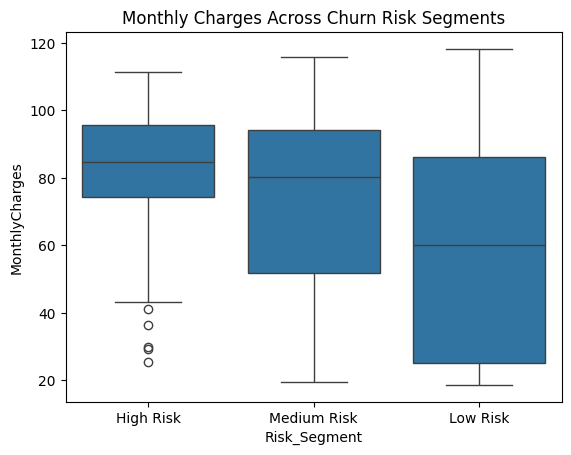

In [ ]:
sns.boxplot(data=risk_df, x='Risk_Segment', y='MonthlyCharges')
plt.title("Monthly Charges Across Churn Risk Segments")
plt.show()